In [1]:
import pandas as pd

# Class từ file data_pipeline.py
from data_pipeline import SalesDataPipeline 

if __name__ == "__main__":
    # Khởi tạo Pipeline
    pipeline = SalesDataPipeline(train_path='data/sales.csv', test_path='data/sample_submission.csv')
    
    # Chạy chuỗi khám bệnh và xử lý
    pipeline.load_data()
    pipeline.inspect_and_fix_dates()
    pipeline.inspect_and_fix_anomalies()
    base_data = pipeline.prepare_master_data()
    
    # Xem kết quả
    print("\n--- XEM TRƯỚC 5 DÒNG DỮ LIỆU ---")
    display(base_data.head())

[1/4] Đang nạp dữ liệu...

[2/4] Đang chẩn đoán Trục thời gian...
   -> Giai đoạn: 2012-07-04 đến 2022-12-31
   -> Số ngày thực tế / Kỳ vọng: 3833 / 3833
Chuỗi thời gian hoàn toàn liền mạch.

[3/4] Đang chẩn đoán Dữ liệu dị thường (Anomalies)...
Không có dữ liệu trùng lặp.
Không có giá trị tài chính âm.
Không phát hiện ngoại lai gây nhiễu nghiêm trọng.

[4/4] Đang tổng hợp Master Data và trích xuất đặc trưng...
HOÀN TẤT GIAI ĐOẠN 1: Dữ liệu đã sẵn sàng để Feature Engineering!

--- XEM TRƯỚC 5 DÒNG DỮ LIỆU ---


,Date,Revenue,COGS,is_test,day_of_week,day_of_month,month,year,is_weekend
0,2012-07-04,5123547.94,3982991.19,0,2,4,7,2012,0
1,2012-07-05,2751773.45,2150580.23,0,3,5,7,2012,0
2,2012-07-06,3054029.42,2517632.84,0,4,6,7,2012,0
3,2012-07-07,2667930.94,2108246.62,0,5,7,7,2012,1
4,2012-07-08,2360851.90,1808622.79,0,6,8,7,2012,1


In [2]:
# IMPORT CLASS 
from feature_engineer import FeatureEngineer

# GỌI FEATURE ENGINEERING 
engineer = FeatureEngineer(master_df=base_data, data_dir='data/')

# Nối chuỗi đúng tên các hàm đã định nghĩa trong class
final_data = (engineer
              .add_promotions()           # Bước 1: Kéo bảng khuyến mãi
              .add_web_traffic()          # Bước 2: Kéo traffic
              .add_inventory()            # Bước 3: Kéo tồn kho
              .add_sales_lags()           # Bước 4: Lịch sử doanh thu (Đã sửa tên)
              .add_calendar_events()      # Bước 5: Sự kiện Lễ/Lương (Đã sửa tên)
              .add_proximity_features()   # GP 2: Thời gian chờ đợi
              .add_momentum_features()    # GP 3: Động lượng và Gia tốc
              .add_feature_interactions() # GP 4: Siêu Tương tác chéo
              .get_data())

# Lọc ra tất cả các cột mang kiểu Số (Int, Float)
numeric_cols = final_data.select_dtypes(include=['number']).columns

# CHỈ điền 0 vào các khoảng trống của những cột Số này
final_data[numeric_cols] = final_data[numeric_cols].fillna(0) 

display(final_data.head())

[1/4] Đang xử lý bảng Promotions...
[2/4] Đang xử lý bảng Web Traffic (Chỉ lấy Lag 1)...
[3/4] Đang xử lý bảng Inventory (Gom nhóm và Forward Fill)...
[4/4] Đang tạo các biến Trễ Doanh thu (Lags & Rolling)...
[5/5] Đang đánh dấu các (Siêu Sale, Nhận lương)...
[6] Đang tính toán...
[7] Đang tính toán Động lượng và Gia tốc...
[8] Đang kết hợp các Siêu Tương tác chéo...
HOÀN TẤT QUÁ TRÌNH FEATURE ENGINEERING!


,Date,Revenue,COGS,is_test,day_of_week,day_of_month,month,year,is_weekend,active_promos_count,...,days_to_payday,days_to_double_day,revenue_lag_2,revenue_lag_3,revenue_diff_1,revenue_diff_7,revenue_acceleration,weekend_x_payday,promo_x_weekend,sessions_per_dayofweek
0,2012-07-04,5123547.94,3982991.19,0,2,4,7,2012,0,0.0,...,1,3,0.00,0.00,0.00,0.0,0.00,0,0,0.0
1,2012-07-05,2751773.45,2150580.23,0,3,5,7,2012,0,0.0,...,0,2,0.00,0.00,5123547.94,0.0,5123547.94,0,0,0.0
2,2012-07-06,3054029.42,2517632.84,0,4,6,7,2012,0,0.0,...,9,1,5123547.94,0.00,-2371774.49,0.0,-7495322.43,0,0,0.0
3,2012-07-07,2667930.94,2108246.62,0,5,7,7,2012,1,0.0,...,8,0,2751773.45,5123547.94,302255.97,0.0,2674030.46,0,0,0.0
4,2012-07-08,2360851.90,1808622.79,0,6,8,7,2012,1,0.0,...,7,30,3054029.42,2751773.45,-386098.48,0.0,-688354.45,0,0,0.0


In [3]:
# Lưu bảng dữ liệu cuối cùng ra thành file CSV 
final_data.to_csv('data/final_data_ready.csv', index=False)

Hệ số Skewness của Doanh thu là: 1.30


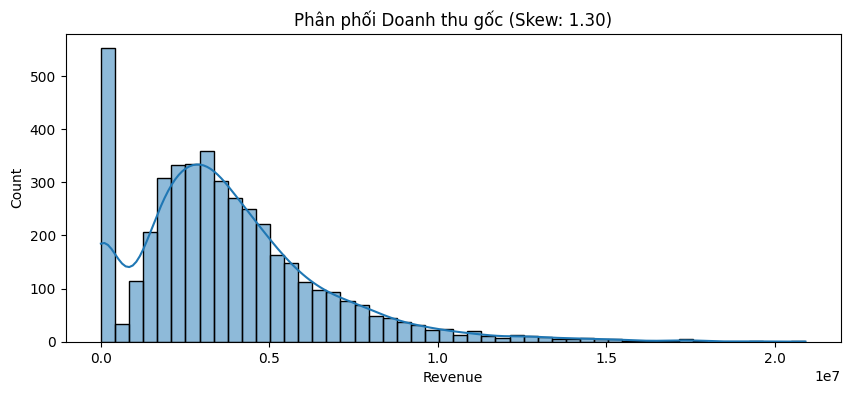

Dữ liệu lệch phải quá nặng! Cần áp dụng Log Transform.
Skewness sau khi nắn: -2.21 (Đã mượt hơn rất nhiều!)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. KIỂM TRA BẰNG TOÁN HỌC
skew_score = final_data['Revenue'].skew()
print(f"Hệ số Skewness của Doanh thu là: {skew_score:.2f}")

# 2. Trực quan hóa
plt.figure(figsize=(10, 4))
sns.histplot(final_data['Revenue'], bins=50, kde=True)
plt.title(f"Phân phối Doanh thu gốc (Skew: {skew_score:.2f})")
plt.show()

# 3. RA QUYẾT ĐỊNH 
if skew_score > 1:
    print("Dữ liệu lệch phải quá nặng! Cần áp dụng Log Transform.")
    
    # Nắn gân dữ liệu bằng log1p (log(1+x) để tránh lỗi với số 0)
    final_data['Revenue_Log'] = np.log1p(final_data['Revenue'])
    
    # In ra để xem kết quả sau phẫu thuật
    new_skew = final_data['Revenue_Log'].skew()
    print(f"Skewness sau khi nắn: {new_skew:.2f} (Đã mượt hơn rất nhiều!)")
    
    # Đổi Target từ Revenue sang Revenue_Log cho mô hình học 
    TARGET = 'Revenue_Log'
else:
    print("Dữ liệu khá chuẩn.")
    TARGET = 'Revenue'

In [ ]:
from model_benchmarker import ModelBenchmarker

# KHAI BÁO TÍNH NĂNG 
SAFE_FEATURES = [
    # Nhóm Lịch & Sự kiện
    'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 
    'is_promo_active', 'active_promos_count', 'is_payday', 'is_double_day', 'is_christmas',
    
    # Nhóm Trí nhớ
    'sessions_lag_1', 'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_mean_7',
    
    # Nhóm Khoảng cách (GP 2)
    'days_to_payday', 'days_to_double_day',
    
    # Nhóm Động lượng (GP 3)
    'revenue_diff_1', 'revenue_diff_7', 'revenue_acceleration',
    
    # Nhóm Tương tác (GP 4)
    'weekend_x_payday', 'promo_x_weekend', 'sessions_per_dayofweek'
] 

# Đã bổ sung 2 cột rolling mới vào đây để tránh NaN
COLS_TO_FILL = [
    'sessions_lag_1', 
    'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_30', 
    'revenue_rolling_mean_7', 'revenue_rolling_mean_30', 'revenue_rolling_std_7',
    'total_stock_on_hand', 'total_stockouts'
]

final_data[COLS_TO_FILL] = final_data[COLS_TO_FILL].fillna(0)

benchmarker_rev = ModelBenchmarker(
    data=final_data, 
    features=SAFE_FEATURES, 
    target_col=TARGET, 
    val_start_date='2022-07-01'
)

benchmarker_rev = ModelBenchmarker(
    data=final_data, 
    features=SAFE_FEATURES, 
    target_col=TARGET, 
    val_start_date='2022-07-01'
)

benchmarker_rev.prepare_data()

# CHẠY CẢ 3 THUẬT TOÁN VỚI OPTUNA
models_to_tune = ['LightGBM', 'XGBoost', 'CatBoost']
for model in models_to_tune:
    benchmarker_rev.tune_with_optuna(model_name=model, n_trials=15)

# 3 bản Gốc và 3 bản Optuna Tuned
leaderboard = (benchmarker_rev 
               .run_experiments()
               .show_leaderboard())

print("\nHOÀN TẤT TOÀN BỘ QUÁ TRÌNH PIPELINE!")

Đang cắt dữ liệu tại mốc: 2022-07-01...
   -> Tập Train (Học):     3649 ngày
   -> Tập Validation (Thi): 184 ngày

BẮT ĐẦU TỐI ƯU HÓA BẰNG OPTUNA [LightGBM]...


  0%|          | 0/15 [00:00<?, ?it/s]

Đã thêm [LightGBM_Optuna_Tuned]!

BẮT ĐẦU TỐI ƯU HÓA BẰNG OPTUNA [XGBoost]...


  0%|          | 0/15 [00:00<?, ?it/s]

Đã thêm [XGBoost_Optuna_Tuned]!

BẮT ĐẦU TỐI ƯU HÓA BẰNG OPTUNA [CatBoost]...


  0%|          | 0/15 [00:00<?, ?it/s]

Đã thêm [CatBoost_Optuna_Tuned]!

BẮT ĐẦU DỰ BÁO: REVENUE_LOG...
Đang huấn luyện [LightGBM]...
Đang huấn luyện [XGBoost]...
Đang huấn luyện [CatBoost]...
Đang huấn luyện [LightGBM_Optuna_Tuned]...
Đang huấn luyện [XGBoost_Optuna_Tuned]...
Đang huấn luyện [CatBoost_Optuna_Tuned]...

BẢNG XẾP HẠNG MÔ HÌNH


,Model,MAE,RMSE,R2_Score
0,LightGBM,483104.84,639965.37,0.7337
4,XGBoost_Optuna_Tuned,484688.88,646064.06,0.7286
1,XGBoost,483583.34,647303.63,0.7275
5,CatBoost_Optuna_Tuned,487982.94,665570.37,0.7119
3,LightGBM_Optuna_Tuned,489806.21,665958.86,0.7116
2,CatBoost,488676.87,666936.32,0.7107



HOÀN TẤT TOÀN BỘ QUÁ TRÌNH PIPELINE!


In [5]:
# ========================================================
# 1. KHAI BÁO KHO VŨ KHÍ (Cập nhật đầy đủ GP 2, 3, 4)
# ========================================================
SAFE_FEATURES = [
    # Nhóm Lịch & Sự kiện
    'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 
    'is_promo_active', 'active_promos_count', 'is_payday', 'is_double_day', 'is_christmas',
    
    # Nhóm Trí nhớ
    'sessions_lag_1', 'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_mean_7',
    
    # Nhóm Khoảng cách (GP 2)
    'days_to_payday', 'days_to_double_day',
    
    # Nhóm Động lượng (GP 3)
    'revenue_diff_1', 'revenue_diff_7', 'revenue_acceleration',
    
    # Nhóm Tương tác (GP 4)
    'weekend_x_payday', 'promo_x_weekend', 'sessions_per_dayofweek'
]

# ========================================================
# 2. KHỞI ĐỘNG NHÀ MÁY DỰ BÁO
# ========================================================
from financial_forecaster import FinancialForecaster

print("\n" + "="*50 + "\n[PHASE 4] DỰ BÁO KÉP (BẢN GRANDMASTER)")

forecaster = FinancialForecaster(
    data=final_data, 
    features=SAFE_FEATURES,
    targets=['Revenue_Transformed', 'COGS_Transformed'] 
)

submission = (forecaster
              .prepare_data()
              .train_and_predict()
              .generate_report(export_path='submission_grandmaster.csv'))


[PHASE 4] DỰ BÁO KÉP (BẢN GRANDMASTER)
[1/3] Đang nhào nặn dữ liệu bằng PowerTransformer...
[2/3] LightGBM đang phân tích và dự báo...
   -> Đang huấn luyện mô hình cho: Revenue
   -> Đang huấn luyện mô hình cho: COGS
[3/3] Đang xuất Báo cáo nộp bài...
File nộp bài lưu tại: submission_grandmaster.csv


,Date,Revenue,COGS
3833,2023-01-01,1.795425e+06,1.581746e+06
3834,2023-01-02,9.800003e+05,8.573655e+05
3835,2023-01-03,1.079449e+06,1.018092e+06
3836,2023-01-04,1.123705e+06,1.031155e+06
3837,2023-01-05,1.081957e+06,1.008101e+06
3838,2023-01-06,1.026572e+06,9.693681e+05
3839,2023-01-07,1.058159e+06,1.022295e+06
3840,2023-01-08,1.378610e+06,1.221183e+06
3841,2023-01-09,1.543718e+06,1.364885e+06
3842,2023-01-10,1.419357e+06,1.258123e+06
